# Installation:
make sure to load the src folder of the github. src.mlg_sort.py contains the sorting algorithm\
optionaly: pip install squarenet (just for preloaded datasets, and grid visualisation)

In [1]:
from src.mlg_sort import monotonic_lagrangian_sort

In [2]:
from  squarenet import SquareNet, samplepoints
def show_result(X, shape, animate = False):
    """ can also be animated with animate = True (slower). This plot allow to visualise the grid as a mesh based on the [i, j, k] index"""
    d = X.shape[-1]
    sn = SquareNet(gridshape = shape)
    sn.pointsmaped = X.reshape(*shape, d)
    sn.plot(style = "mesh", save = False, animate = animate)
     #neighbormap counts the number of points found at a given relative delta = [i'-i, j'-j, k] such that
     #P[i', j', k] = argmin(i', j') dist(P[i,j,k], P[i',j',k])
    sn.neighbormap(projection = (0, 1)) #can also be projection = (1, 2)/(0, 1)

# Availabe methods: 
spiky, holy, gaussian, square, france, germany

In [3]:

def sample(method, size):
    return samplepoints(method = method, size = size, plot_points = False)

# Monotonic lagrangian sort performs:

- kdtree warmstart
- sorting procedure at given level: 
Level = 1 -> pure cartesian x/y/z/ axes,\
 Level = 2 -> add xy/xz/yz diagonals,\
  Level = 3 -> add xyz diagonals

- this is a pure python implementation for now, and thus much slower than the c++ version

In [10]:
nx, ny = 513, 513
d = 2
shape = (nx, ny)
X = sample("france", (nx*ny, d))
X = monotonic_lagrangian_sort(X, shape = shape, level = 2)

performing kdtree initialisation...
done
--------------------it: 19
---------it: 8


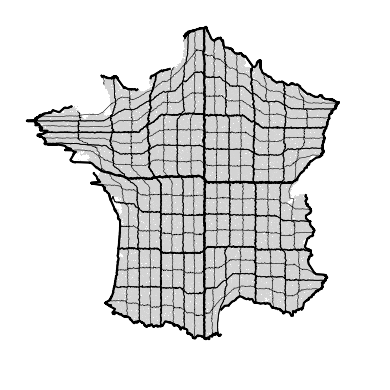

neighbor map on axes (0, 1)
                                                                                    
                                                                                    
                                                                                    
                                                                                    
                                           1                                        
                                                                    1               
                                           2         1                              
                                 3    2    4    3    1                              
                            1   16   33   35   28   13    4    1                    
                  4    3   17  119  501  736  404   94   17    1    1               
                  1    7   45  402 2929 5946 2641  430   60   11    1    1          
                  1    9   51  671 57

In [11]:
show_result(X, shape)

In [7]:
nx, ny, nz = 50, 51, 52
d = 3
shape = (nx, ny, nz)
X = sample("ball", (nx*ny*nz, d))
X = monotonic_lagrangian_sort(X, shape = shape, level = 3, init = "none")

---------------it: 14


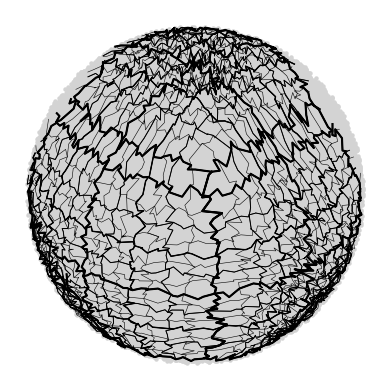

neighbor map on axes (0, 1)
                  1    5    1               
             1   25   48   12    4    1     
        3   53  329  753  291   57    2     
       10  250 2756 6460 2826  299   11    1
       27  568 6130    ■ 6072  579   25     
   1   10  291 2764 6369 2707  273   10    1
        2   41  316  755  334   40    6     
        1    3   11   57   23    3          
                       3    1               


In [8]:
show_result(X, shape)

This one is a tricky geometry.\ Just to show remind that we need to be carefull \
when they are peaks and other storng irregularitys in the dataset. 

I'm working with algorithm improvements to better support very irregular geometryes

In [4]:
nx, ny, nz = 50, 51, 52
d = 3
shape = (nx, ny, nz)
X = sample("spiky", (nx*ny*nz, d))
X = monotonic_lagrangian_sort(X, shape = shape, level = 3, init = "none")

--------------------it: 19
--------------------it: 19


c:\Users\arman\squarenet2\src\mlg_sort.py:238: UserWarning: Convergence failed, increase n-iter
  warnings.warn("Convergence failed, increase n-iter")


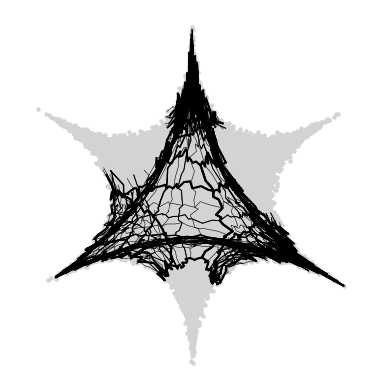

neighbor map on axes (0, 1)
                                                                              2                                                                           
                                                                              3                                                                           
                                                                              5                                                                           
                                                                         1    6                                                                           
                                                                         1    7    2                                                                      
                                                                         3   12    3                                                                      
                                          

In [5]:
show_result(X, shape)